In [1]:
# -- Set Project root
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(PROJECT_ROOT)

%reload_ext autoreload
%autoreload 2

/teamspace/studios/this_studio/Airport-AI


In [3]:
# -- Load configuration
from airport_ai.config import config

print("Config loaded")

print(
    config.get("cameras")
)

print(
    config.get("database")
)

print(config.get("dashboard"))

Config loaded
[{'camera_id': 'GATE_A01', 'camera_name': 'Gate A01', 'source': 'data/videos/04_sample.mp4'}, {'camera_id': 'GATE_B03', 'camera_name': 'Gate B03', 'source': 'data/videos/02_sample.mp4'}, {'camera_id': 'GATE_C04', 'camera_name': 'Gate C04', 'source': 'data/videos/03_sample.mp4'}]
{'path': 'data/database/airport_monitor.db'}
{'runtime_db': 'data/database/runtime.db', 'refresh_seconds': 2}


In [4]:
# -- Test video source
from airport_ai.streams.video_source import VideoSource

video_path = config.resolve_path(
    config.get("cameras")[1]["source"]
)

source = VideoSource(video_path)

ok, frame = source.read()

source.release()

print("Read:", ok)

if frame is not None:
    print(frame.shape)

Opening Video: /teamspace/studios/this_studio/Airport-AI/data/videos/02_sample.mp4
Read: True
(1080, 1920, 3)


In [5]:
# -- Build complete application
from airport_ai.app.builder import ApplicationBuilder


builder = ApplicationBuilder(
    config
)

application = builder.build()

print(
    "Pipelines:",
    len(application.pipelines)
)

Database: /teamspace/studios/this_studio/Airport-AI/data/database/airport_monitor.db
Loaded model: /teamspace/studios/this_studio/Airport-AI/runs/train/airport_yolo26n/weights/best.pt
Device: cpu
Classes: {0: 'aircraft', 1: 'airport_tug', 2: 'cone', 3: 'ground_support_equipment', 4: 'safety_vest', 5: 'worker'}
Opening Video: /teamspace/studios/this_studio/Airport-AI/data/videos/04_sample.mp4
Opening Video: /teamspace/studios/this_studio/Airport-AI/data/videos/02_sample.mp4
Opening Video: /teamspace/studios/this_studio/Airport-AI/data/videos/03_sample.mp4
PIPELINES: {'GATE_A01': <airport_ai.pipeline.camera_pipeline.CameraPipeline object at 0x72d2b071cf50>, 'GATE_B03': <airport_ai.pipeline.camera_pipeline.CameraPipeline object at 0x72d2b06f6ea0>, 'GATE_C04': <airport_ai.pipeline.camera_pipeline.CameraPipeline object at 0x72d2b06f4a40>}
Pipelines: 3


In [6]:
# -- Verify services
pipeline = application.pipelines[0]

print("Camera:")
print(
    pipeline.camera_id
)

print("\nInference:")
print(
    type(pipeline.inference_engine)
)

print("\nTracker:")
print(
    type(pipeline.tracker)
)

print("\nVisualizer:")
print(
    type(pipeline.visualizer)
)

print("\nStorage:")
print(
    type(pipeline.storage_writer)
)

KeyError: 0

In [ ]:
# -- Verify AsyncCamera
camera = pipeline.camera


print(
    "Camera object:",
    type(camera)
)


print(
    "FrameBuffer object:",
    type(camera.buffer)
)

print(
    "Running:",
    camera.running
)


print(
    "Buffer size:",
    camera.buffer.size()
)

Camera object: <class 'airport_ai.streams.camera.AsyncCamera'>
FrameBuffer object: <class 'airport_ai.streams.buffer.FrameBuffer'>
Running: True
Buffer size: 30


In [ ]:
# -- Verify if the thread died because of EOF
camera = pipeline.camera

print("Running:", camera.running)

print(
    "Thread alive:",
    camera.thread.is_alive()
)

Running: True
Thread alive: True


In [ ]:
# -- Check if the video ended
import cv2
print(
    camera.source.cap.isOpened()
)

print(
    camera.source.cap.get(cv2.CAP_PROP_POS_FRAMES)
)

print(
    camera.source.cap.get(cv2.CAP_PROP_FRAME_COUNT)
)

True
81.0
1803.0


In [ ]:
import time

time.sleep(2)


print(
    camera.buffer.size()
)

30


In [ ]:
# -- Read one pipeline frame
output = pipeline.process_frame()


print(
    type(output)
)


if output is not None:
    print(
        output.shape
    )

Updating metrics
{'camera_id': 'GATE_A01', 'fps': 0, 'latency_ms': 3213.6, 'queue_size': 0, 'frames_processed': 1, 'status': 'STOPPED'}

===== RUUNTIME METRICS =====
{'camera_id': 'GATE_A01', 'fps': 0, 'latency_ms': 3213.6, 'queue_size': 0, 'frames_processed': 1, 'status': 'STOPPED'}
Capture: 0.02 ms
YOLO: 3203.44 ms
Tracking: 0.14 ms
Analytics: 7.94 ms
Storage: 0.00 ms
Visualization: 0.02 ms
<class 'numpy.ndarray'>
(720, 1280, 3)


In [ ]:
# -- Verify YOLO output
frame = pipeline.camera.read()

detections = pipeline.inference_engine.detect(
    frame
)


print(
    "Detections:",
    len(detections)
)


if detections:
    print(
        type(detections[0])
    )

Detections: 10
<class 'airport_ai.inference.detection.Detection'>


In [ ]:
# Verify Tracker conversion
tracks = pipeline.tracker.update(
    detections
)


print(
    "Tracks:",
    len(tracks)
)


if tracks:
    print(
        type(tracks[0])
    )

Tracks: 1
<class 'airport_ai.inference.tracked_object.TrackedObject'>


In [ ]:
# -- Verify analytics
(
    safety_events,
    ppe_events,
    fod_events
) = pipeline.analytics_executor.evaluate(
    tracks,
    pipeline.turnaround,
    pipeline.ppe,
    pipeline.fod
)


print(
    "Safety:",
    len(safety_events)
)

print(
    "PPE:",
    len(ppe_events)
)

print(
    "FOD:",
    len(fod_events)
)

Safety: 0
PPE: 0
FOD: 0


In [ ]:
# -- Verify Storage writer
for event in safety_events:

    pipeline.storage_writer.submit(
        pipeline.camera_id,
        "TURNAROUND",
        event
    )


print(
    "Queue:",
    pipeline.storage_writer.queue.qsize()
)

Queue: 0


In [ ]:
# -- Confirm writer thread
print(
    pipeline.storage_writer.thread.is_alive()
)

True


In [ ]:
# Allow databse flush
import time

time.sleep(3)

In [ ]:
# -- Verify SQLite persistence
repository = pipeline.repository


events = repository.get_recent(
    limit=10
)


print(
    "Stored events:",
    len(events)
)


for e in events:
    print(e)

Stored events: 10
('GATE_A01', '2026-07-30T19:55:53.345959', 'PPE', 7, 'worker', 'MISSING_SAFETY_VEST', 'MEDIUM', 'Worker 7 is not wearing safety vest.')
('GATE_A01', '2026-07-30T19:55:53.125670', 'PPE', 5, 'worker', 'MISSING_SAFETY_VEST', 'MEDIUM', 'Worker 5 is not wearing safety vest.')
('GATE_A01', '2026-07-30T19:22:25.519138', 'PPE', 88, 'worker', 'MISSING_SAFETY_VEST', 'MEDIUM', 'Worker 88 is not wearing safety vest.')
('GATE_A01', '2026-07-30T19:22:25.519122', 'PPE', 60, 'worker', 'MISSING_SAFETY_VEST', 'MEDIUM', 'Worker 60 is not wearing safety vest.')
('GATE_A01', '2026-07-30T19:22:25.519088', 'PPE', 71, 'worker', 'MISSING_SAFETY_VEST', 'MEDIUM', 'Worker 71 is not wearing safety vest.')
('GATE_A01', '2026-07-30T19:22:25.418061', 'PPE', 88, 'worker', 'MISSING_SAFETY_VEST', 'MEDIUM', 'Worker 88 is not wearing safety vest.')
('GATE_A01', '2026-07-30T19:22:25.418052', 'PPE', 60, 'worker', 'MISSING_SAFETY_VEST', 'MEDIUM', 'Worker 60 is not wearing safety vest.')
('GATE_A01', '2026-0

Updating metrics
deque([1785441461.0475905, 1785441465.1336625], maxlen=100)
Elapsed: 4.086071968078613
Frames: 2
deque([1785441461.0475905, 1785441465.1336625], maxlen=100)
Elapsed: 4.086071968078613
Frames: 2
{'camera_id': 'GATE_A01', 'fps': 0.49, 'latency_ms': 1630.12, 'queue_size': 0, 'frames_processed': 2, 'status': 'WARNING'}

===== RUUNTIME METRICS =====
deque([1785441461.0475905, 1785441465.1336625], maxlen=100)
Elapsed: 4.086071968078613
Frames: 2
deque([1785441461.0475905, 1785441465.1336625], maxlen=100)
Elapsed: 4.086071968078613
Frames: 2
{'camera_id': 'GATE_A01', 'fps': 0.49, 'latency_ms': 1630.12, 'queue_size': 0, 'frames_processed': 2, 'status': 'WARNING'}
Capture: 0.02 ms
YOLO: 40.41 ms
Tracking: 0.59 ms
Analytics: 0.38 ms
Storage: 0.00 ms
Visualization: 2.82 ms


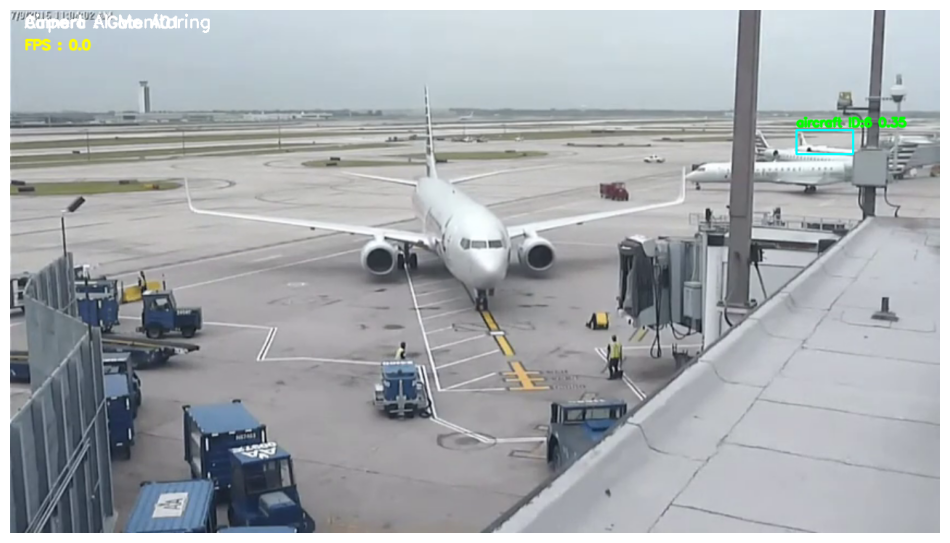

In [ ]:
# -- Verify Visualization
import matplotlib.pyplot as plt

frame = None

while frame is None:
    frame = pipeline.process_frame()

plt.figure(figsize=(12,7))

plt.imshow(
    frame[:,:,::-1]
)

plt.axis("off")
plt.show()

In [ ]:
# -- Runtime metrics
print(
    pipeline.metrics.health()
)

deque([1785441461.0475905, 1785441465.1336625], maxlen=100)
Elapsed: 4.086071968078613
Frames: 2
deque([1785441461.0475905, 1785441465.1336625], maxlen=100)
Elapsed: 4.086071968078613
Frames: 2
{'camera_id': 'GATE_A01', 'fps': 0.49, 'latency_ms': 1630.12, 'queue_size': 0, 'frames_processed': 2, 'status': 'WARNING'}


In [ ]:
# -- Profiler report
if pipeline.profiler:

    report = pipeline.profiler.summary()

    for stage, values in report.items():

        print(
            stage,
            values
        )

runtime {'seconds': 0.87, 'fps': 0.0}
visualization {'frames_rendered': 0, 'frames_skipped': 0, 'cache_hits': 0, 'cache_misses': 0, 'cache_hit_rate': 0.0}


In [ ]:
# Benchmarking
import time

N = 100

start = time.perf_counter()

for _ in range(N):
    pipeline.process_frame()

elapsed = time.perf_counter() - start

fps = N / elapsed
latency = elapsed / N * 1000

print(f"FPS: {fps:.2f}")
print(f"Latency: {latency:.2f} ms")

[MEDIUM] GATE_A01 PPE: Worker 5 is not wearing safety vest.
deque([1785441461.0475905, 1785441465.1336625], maxlen=100)
Elapsed: 4.086071968078613
Frames: 2
Updating metrics
deque([1785441461.0475905, 1785441465.1336625, 1785441466.2042844], maxlen=100)
Elapsed: 5.156693935394287
Frames: 3
deque([1785441461.0475905, 1785441465.1336625, 1785441466.2042844], maxlen=100)
Elapsed: 5.156693935394287
Frames: 3
{'camera_id': 'GATE_A01', 'fps': 0.58, 'latency_ms': 1111.09, 'queue_size': 0, 'frames_processed': 3, 'status': 'WARNING'}

===== RUUNTIME METRICS =====
deque([1785441461.0475905, 1785441465.1336625, 1785441466.2042844], maxlen=100)
Elapsed: 5.156693935394287
Frames: 3
deque([1785441461.0475905, 1785441465.1336625, 1785441466.2042844], maxlen=100)
Elapsed: 5.156693935394287
Frames: 3
{'camera_id': 'GATE_A01', 'fps': 0.58, 'latency_ms': 1111.09, 'queue_size': 0, 'frames_processed': 3, 'status': 'WARNING'}
Capture: 0.04 ms
YOLO: 54.36 ms
Tracking: 0.42 ms
Analytics: 1.20 ms
Storage: 14.1